In [10]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

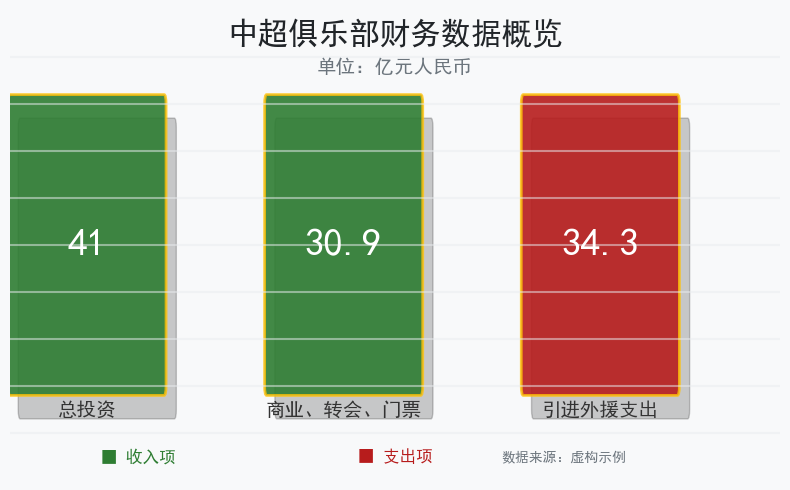

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 数据
labels = ["总投资", "商业、转会、门票", "引进外援支出"]
values = [41, 30.9, 34.3]
colors = ["#2E7D32", "#2E7D32", "#B71C1C"]  # 绿色和红色
highlight_color = "#FFC107"  # 黄色高亮

# 创建画布
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#f8f9fa')
ax.set_ylim(0, 1)
ax.set_xlim(0, len(values) * 2.5)  # 增加x轴空间
ax.axis('off')

# 绘制背景网格
for i in range(1, 10):
    ax.axhline(y=i*0.1, color='#e9ecef', linestyle='-', alpha=0.5)

# 绘制数据块
for i in range(len(values)):
    # 添加阴影效果
    shadow = patches.FancyBboxPatch(
        (i * 2.5 + 0.1, 0.15), 1.5, 0.6, 
        boxstyle=patches.BoxStyle("Round", pad=0.02),
        facecolor='black', alpha=0.2
    )
    ax.add_patch(shadow)
    
    # 绘制主方块
    rect = patches.FancyBboxPatch(
        (i * 2.5, 0.2), 1.5, 0.6, 
        boxstyle=patches.BoxStyle("Round", pad=0.02),
        facecolor=colors[i], edgecolor="none", alpha=0.9
    )
    ax.add_patch(rect)
    
    # 添加边框高亮
    highlight = patches.FancyBboxPatch(
        (i * 2.5, 0.2), 1.5, 0.6, 
        boxstyle=patches.BoxStyle("Round", pad=0.02),
        facecolor='none', edgecolor=highlight_color, 
        linewidth=2, alpha=0.8
    )
    ax.add_patch(highlight)
    
    # 绘制数值文字
    ax.text(
        i * 2.5 + 0.75, 0.5, f"{values[i]}", 
        ha="center", va="center", fontsize=28, 
        color="white", fontweight='bold',
        bbox=dict(facecolor='none', edgecolor='none')
    )
    
    # 绘制标签文字
    ax.text(
        i * 2.5 + 0.75, 0.15, labels[i], 
        ha="center", va="center", fontsize=14, 
        color="#333333", fontweight='bold'
    )

# 添加标题
ax.text(
    (len(values) * 2.5) / 2, 0.95, "中超俱乐部财务数据概览", 
    ha="center", va="center", fontsize=22, 
    color="#212529", fontweight='bold'
)

# 添加副标题
ax.text(
    (len(values) * 2.5) / 2, 0.88, "单位：亿元人民币", 
    ha="center", va="center", fontsize=14, 
    color="#6c757d"
)

# 添加图例
ax.text(
    1.25, 0.05, "■ 收入项", 
    ha="center", va="center", fontsize=12, 
    color="#2E7D32"
)
ax.text(
    3.75, 0.05, "■ 支出项", 
    ha="center", va="center", fontsize=12, 
    color="#B71C1C"
)

# 添加数据来源
ax.text(
    (len(values) * 2.5) - 1.5, 0.05, "数据来源：虚构示例", 
    ha="right", va="center", fontsize=10, 
    color="#6c757d"
)

# 微调布局
plt.tight_layout()

# 显示图表
plt.show()    

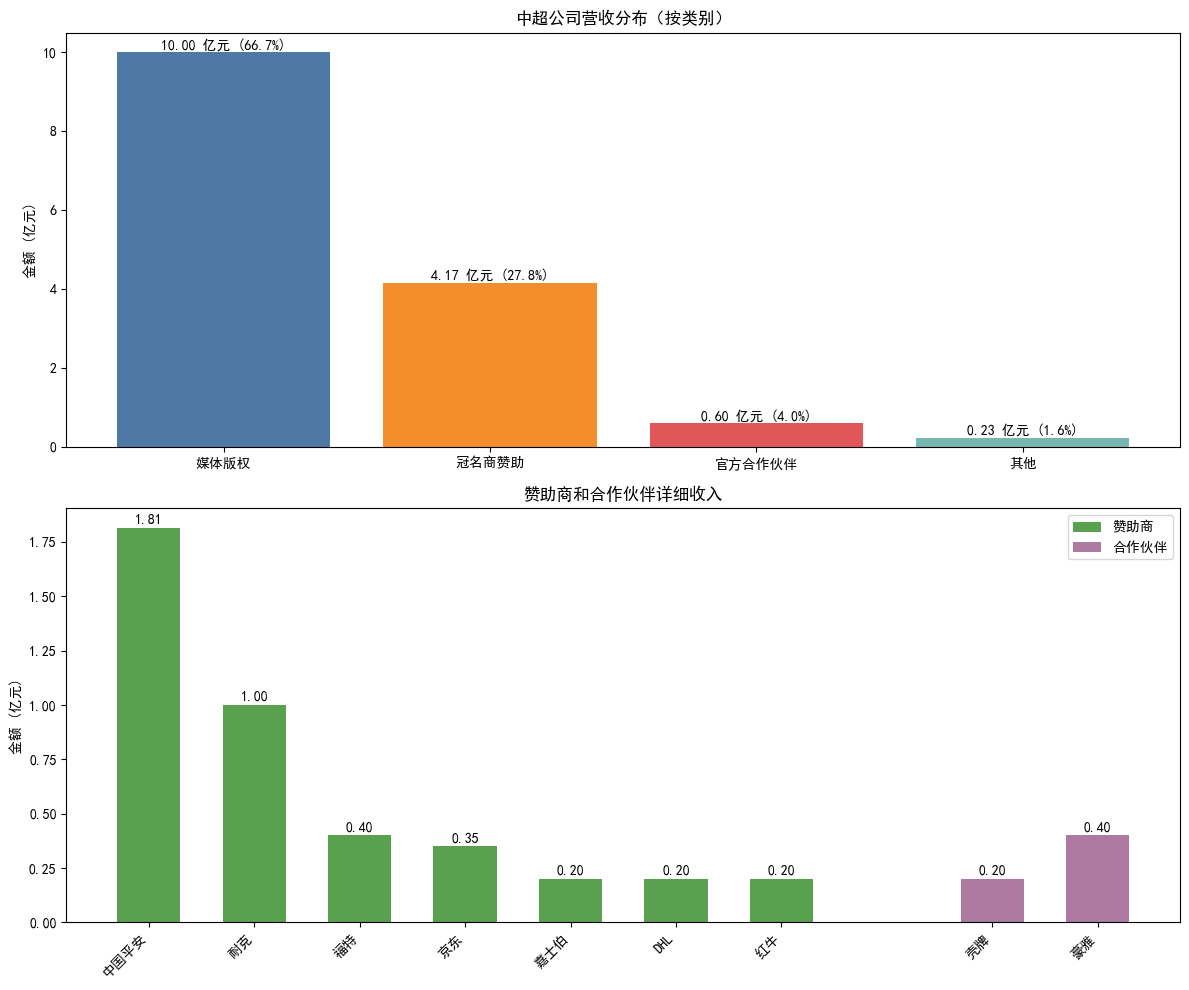

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
total_revenue = 15
media_rights = 10
sponsors = {
    "中国平安": 1.815,
    "耐克": 1,
    "福特": 0.4,
    "京东": 0.35,
    "嘉士伯": 0.2,
    "DHL": 0.2,
    "红牛": 0.2
}
partners = {
    "壳牌": 0.2,
    "豪雅": 0.4
}

# 计算其他收入
other_revenue = total_revenue - media_rights - sum(sponsors.values()) - sum(partners.values())

# 创建画布
plt.figure(figsize=(12, 10))

# 准备条形图数据
categories = ["媒体版权", "冠名商赞助", "官方合作伙伴", "其他"]
values = [media_rights, sum(sponsors.values()), sum(partners.values()), other_revenue]
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

# 绘制主条形图 - 各类收入占比
plt.subplot(2, 1, 1)
bars = plt.bar(categories, values, color=colors)
plt.title('中超公司营收分布（按类别）')
plt.ylabel('金额 (亿元)')

# 在条形上添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f} 亿元 ({height/total_revenue*100:.1f}%)',
             ha='center', va='bottom')

# 绘制赞助商和合作伙伴详细条形图
plt.subplot(2, 1, 2)

# 合并赞助商和合作伙伴数据
sponsor_names = list(sponsors.keys())
sponsor_values = list(sponsors.values())
partner_names = list(partners.keys())
partner_values = list(partners.values())

# 设置条形位置
x_sponsor = np.arange(len(sponsor_names))
x_partner = np.arange(len(partner_names)) + len(sponsor_names) + 1

# 绘制赞助商条形
plt.bar(x_sponsor, sponsor_values, width=0.6, label='赞助商', color='#59a14f')
# 绘制合作伙伴条形
plt.bar(x_partner, partner_values, width=0.6, label='合作伙伴', color='#af7aa1')

# 设置x轴标签和刻度
plt.xticks(list(x_sponsor) + list(x_partner), sponsor_names + partner_names, rotation=45, ha='right')
plt.title('赞助商和合作伙伴详细收入')
plt.ylabel('金额 (亿元)')
plt.legend()

# 在条形上添加数值标签
for i, v in enumerate(sponsor_values):
    plt.text(x_sponsor[i], v + 0.02, f'{v:.2f}', ha='center')
for i, v in enumerate(partner_values):
    plt.text(x_partner[i], v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

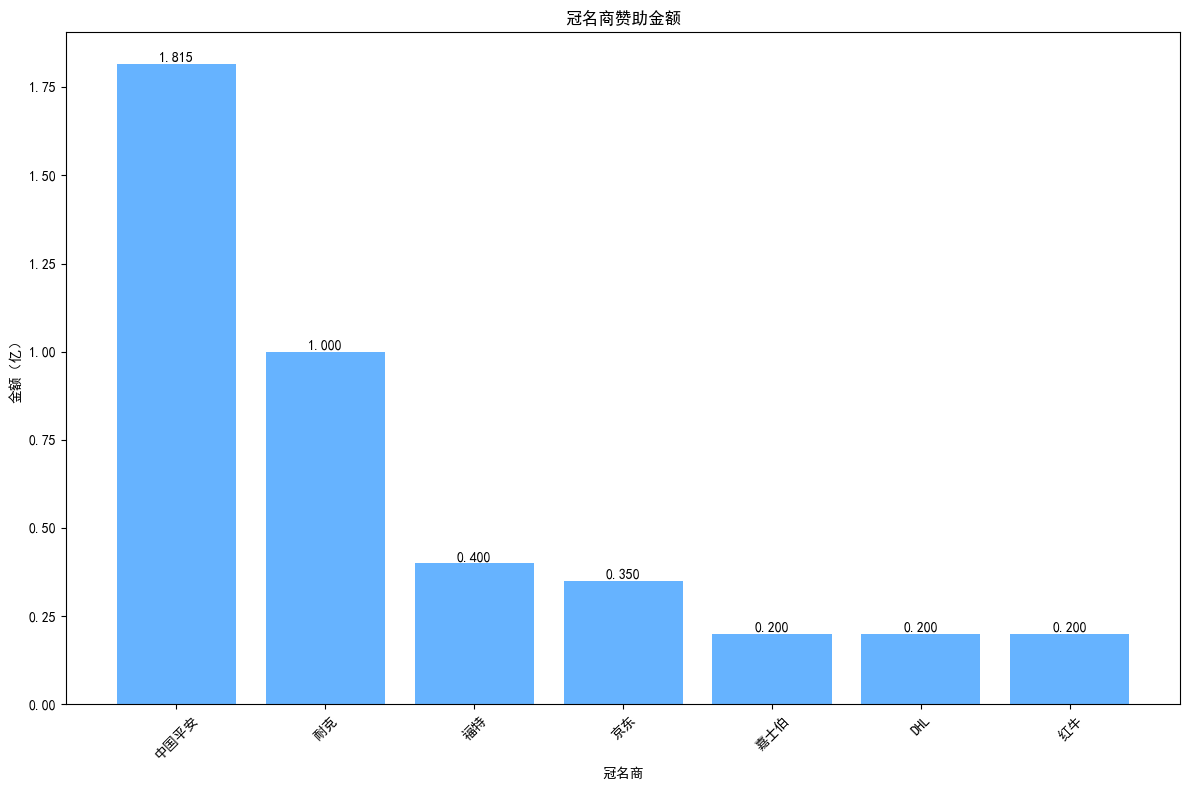

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 冠名商数据
sponsors = {
    "中国平安": 1.815,
    "耐克": 1,
    "福特": 0.4,
    "京东": 0.35,
    "嘉士伯": 0.2,
    "DHL": 0.2,
    "红牛": 0.2
}

# 创建画布
plt.figure(figsize=(12, 8))

# 冠名商赞助柱状图
sponsor_names = list(sponsors.keys())
sponsor_values = list(sponsors.values())
bars = plt.bar(sponsor_names, sponsor_values, color='#66b3ff')
plt.title('冠名商赞助金额')
plt.xlabel('冠名商')
plt.ylabel('金额（亿）')
plt.xticks(rotation=45)

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()    

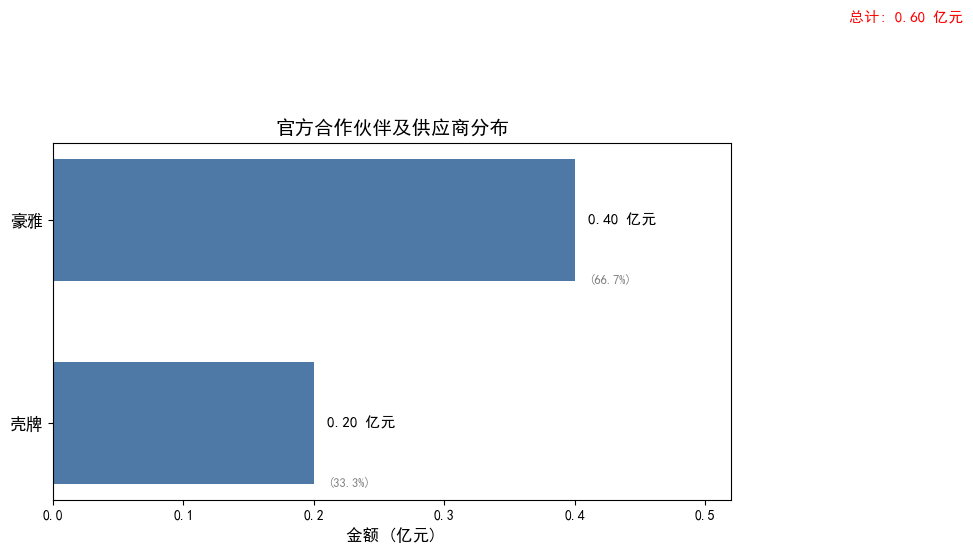

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 官方合作伙伴数据
partners = {
    "壳牌": 0.2,
    "豪雅": 0.4
}

# 计算总金额
total = sum(partners.values())

# 创建画布
plt.figure(figsize=(10, 6))

# 官方合作伙伴水平条形图
partner_names = list(partners.keys())
partner_values = list(partners.values())

# 绘制水平条形图
y_pos = np.arange(len(partner_names))
bars = plt.barh(y_pos, partner_values, align='center', color='#4e79a7', height=0.6)
plt.yticks(y_pos, partner_names, fontsize=12)
plt.xlabel('金额 (亿元)', fontsize=12)
plt.title('官方合作伙伴及供应商分布', fontsize=14)
plt.xlim(0, max(partner_values) * 1.3)  # 调整x轴范围，为标签留出空间

# 在条形上添加数值标签
for i, v in enumerate(partner_values):
    plt.text(v + 0.01, i, f'{v:.2f} 亿元', va='center', fontsize=11)
    plt.text(v + 0.01, i - 0.3, f'({v/total*100:.1f}%)', va='center', fontsize=9, color='gray')

# 添加总计信息
plt.axvline(x=total, color='r', linestyle='--', alpha=0.5)
plt.text(total + 0.01, len(partner_names), f'总计: {total:.2f} 亿元', va='center', fontsize=11, color='red')

plt.tight_layout()
plt.show()

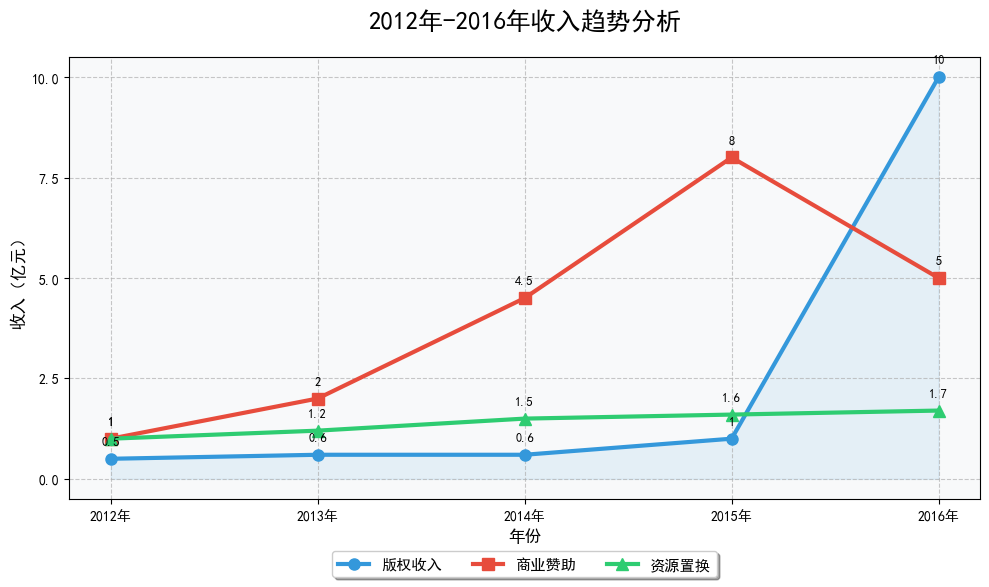

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# 年份
years = np.arange(2012, 2017)  
# 模拟数据，大体贴近原图趋势，版权收入、商业赞助、资源置换
copyright_income = [0.5, 0.6, 0.6, 1, 10]  
sponsorship_income = [1, 2, 4.5, 8, 5]
resource_swap = [1, 1.2, 1.5, 1.6, 1.7]  

# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))  # 增大图表尺寸

# 设置背景网格和颜色
ax.set_facecolor('#f8f9fa')
ax.grid(True, linestyle='--', alpha=0.7)

# 绘制三条折线，使用更美观的颜色和标记
line1, = ax.plot(years, copyright_income, color='#3498db', label='版权收入', linewidth=3, marker='o', markersize=8)
line2, = ax.plot(years, sponsorship_income, color='#e74c3c', label='商业赞助', linewidth=3, marker='s', markersize=8)
line3, = ax.plot(years, resource_swap, color='#2ecc71', label='资源置换', linewidth=3, marker='^', markersize=8)

# 设置标题和副标题
ax.set_title('2012年-2016年收入趋势分析', fontsize=18, fontweight='bold', pad=20)

# 设置坐标轴标签和刻度
ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('收入（亿元）', fontsize=12)
ax.set_xticks(years)
ax.set_xticklabels([f'{year}年' for year in years], fontsize=10)
ax.set_yticks(np.arange(0, 11, 2.5))

# 为每个数据点添加数值标签
for x, y in zip(years, copyright_income):
    ax.annotate(f'{y}', (x, y), textcoords='offset points', 
                xytext=(0,10), ha='center', fontsize=9)
for x, y in zip(years, sponsorship_income):
    ax.annotate(f'{y}', (x, y), textcoords='offset points', 
                xytext=(0,10), ha='center', fontsize=9)
for x, y in zip(years, resource_swap):
    ax.annotate(f'{y}', (x, y), textcoords='offset points', 
                xytext=(0,10), ha='center', fontsize=9)

# 高亮显示版权收入的增长
ax.fill_between(years, copyright_income, 0, color='#3498db', alpha=0.1)

# 调整图例位置和样式
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), 
          fancybox=True, shadow=True, ncol=3, fontsize=11)

plt.tight_layout()  # 调整布局
plt.show()    